In [1]:
!pip install catboost
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 25.4 MB/s eta 0:00:00


In [276]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

In [165]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
import seaborn as sns

In [166]:
import matplotlib.pyplot as plt
import optuna
from matplotlib import rcParams

In [167]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [168]:
import os
os.chdir("/content/drive/MyDrive/데이콘")

# 함수 활용


In [171]:
def major_group(x):
    x = str(x)
    if any(k in x for k in ["통계", "데이터"]): return "stats_data"
    if any(k in x for k in ["컴퓨터", "소프트", "ai", "인공지능", "ICT"]): return "cs_ai"
    if any(k in x for k in ["경영", "경제", "회계"]): return "business"
    if any(k in x for k in ["생명", "화학", "바이오"]): return "bio_chem"
    if any(k in x for k in ["영어", "국어", "문학", "철학"]): return "humanities"
    return "기타"


In [172]:
def merge_rare_train_test(train, test, col, min_count=3, other="NA"):
    vc1 = train[col].value_counts(dropna=False)
    tr_rare = vc1[vc1 <= min_count].index

    vc2 = test[col].value_counts(dropna=False)
    te_rare = vc2[vc2 <= min_count].index

    train[col] = train[col].replace(tr_rare, other)
    test[col]  = test[col].replace(te_rare, other)
    return train, test

In [173]:
def count_by_comma(s: pd.Series) -> pd.Series:
    # 기본 전처리
    s_clean = s.fillna('').astype(str).str.strip()

    # 0으로 처리할 키워드 패턴
    zero_pattern = r'(없음|기타|준비\s*중|na)'

    # 토큰 수 계산: 기본은 1 + comma 수
    base_count = s_clean.str.count(',') + 1

    # 조건별 처리
    result = (
        base_count
        .where(s_clean.ne(''), 0)  # 빈 문자열 → 0
        .where(~s_clean.str.contains(zero_pattern, regex=True), 0)  # 키워드 포함 → 0
    )

    return result.astype(int)

In [174]:
def yes_to_int(s: pd.Series) -> pd.Series:
    return s.fillna('').astype(str).str.lower().isin(['yes', 'True', '1', 'y', '예']).astype(int)

In [175]:
def valid_count(df, cols, exclude_pattern = r'(기타|없음|na)'):
    counts = []

    for c in cols:
        valid = (
            df[c].notna()
            & ~df[c].astype(str).str.contains(exclude_pattern, na=False)
        )
        counts.append(valid.astype(int))

    return pd.concat(counts, axis=1).sum(axis=1)

In [176]:
def summary(df):
    print(f'데이터 세트: {df.shape}')
    summary = pd.DataFrame(df.dtypes, columns=['데이터 타입'])
    summary = summary.reset_index()  # 새로운 인덱스
    summary = summary.rename(columns={'index': '피처'})  # 열 이름 변경
    summary['결측값 수'] = df.isnull().sum().values  # 피처별 결측값 개수
    summary['고윳값 수'] = df.nunique().values  # 피처별 고윳값 개수
    return summary

In [177]:
def plot_one_box(df, col):
    plt.figure(figsize=(4,5))
    sns.boxplot(df[col])
    plt.title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

# 데이터

In [214]:
# 데이터 로드
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv('sample_submission.csv')

In [215]:
X = train.drop(columns='completed').copy()
y = train['completed'].copy()
test_x = test.copy()

In [216]:
summary(X)

데이터 세트: (748, 45)


,피처,데이터 타입,결측값 수,고윳값 수
0,ID,object,0,748
1,generation,int64,0,1
2,school1,int64,0,92
3,major type,object,22,3
4,major1_1,object,20,11
5,major1_2,object,439,10
6,major_data,bool,0,2
7,job,object,0,4
8,class1,int64,0,10
9,class2,float64,579,9


In [217]:
drop_col_na = X.columns[X.isnull().mean() >= 0.9].tolist()

In [218]:
drop_col_na

['class3', 'class4', 'contest_award', 'contest_participation', 'idea_contest']

In [219]:
X = X.drop(columns = drop_col_na)
test_x = test_x.drop(columns = drop_col_na)

In [220]:
X = X.drop(columns = ['ID','generation'])
test_x = test_x.drop(columns = ['ID','generation'])

In [221]:
# 데이터 확인
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 38 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   school1                          748 non-null    int64  
 1   major type                       726 non-null    object 
 2   major1_1                         728 non-null    object 
 3   major1_2                         309 non-null    object 
 4   major_data                       748 non-null    bool   
 5   job                              748 non-null    object 
 6   class1                           748 non-null    int64  
 7   class2                           169 non-null    float64
 8   re_registration                  748 non-null    object 
 9   nationality                      747 non-null    object 
 10  inflow_route                     748 non-null    object 
 11  whyBDA                           748 non-null    object 
 12  what_to_gain          

#데이터 정리

In [222]:
cat_col = X.select_dtypes(include=['object','bool']).columns.tolist()
num_col = X.select_dtypes(exclude=['object','bool']).columns.tolist()

In [223]:
for c in cat_col :
  X[c] = X[c].fillna('na')
  test_x[c] = test_x[c].fillna('na')

In [224]:
for c in num_col :
  X[c] = X[c].fillna(0)
  test_x[c] = test_x[c].fillna(0)

In [225]:
num_col

['school1', 'class1', 'class2', 'completed_semester', 'time_input']

In [226]:
X['completed_semester']

,completed_semester
0,4.0
1,6.0
2,8.0
3,8.0
4,7.0
...,...
743,8.0
744,8.0
745,7.0
746,6.0


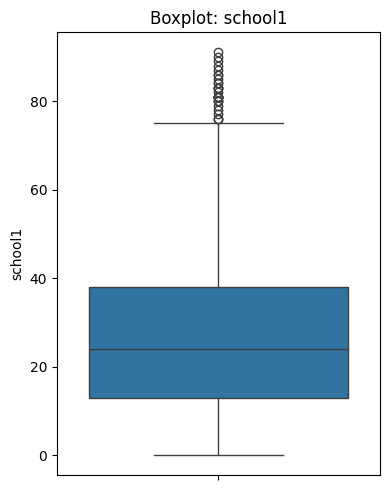

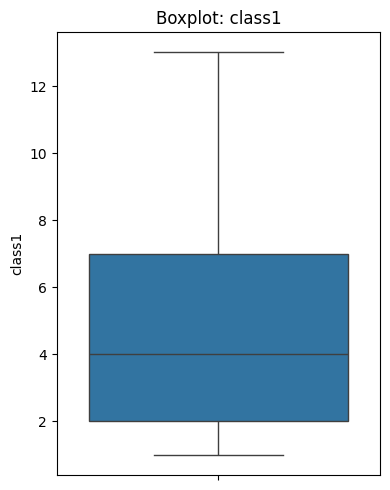

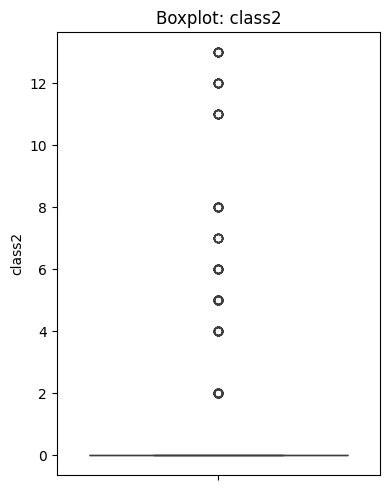

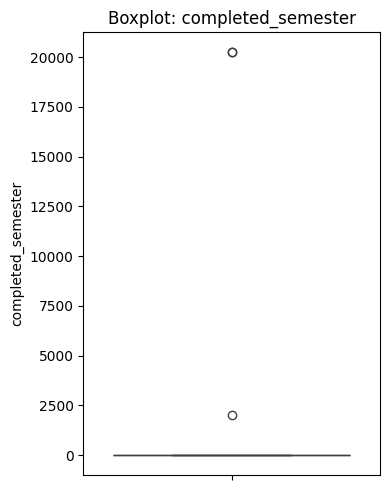

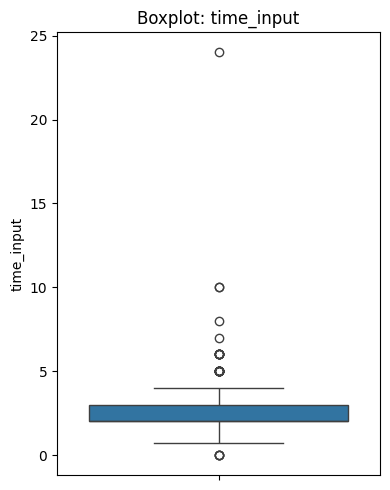

In [227]:
for i in num_col :
  plot_one_box(X,i)  # 타깃명 맞게 수정

In [228]:
X['completed_semester'].value_counts()

,count
completed_semester,
6.00,205
8.00,193
4.00,134
7.00,74
5.00,40
2.00,29
0.00,29
9.00,20
3.00,10


In [229]:
test_x['completed_semester'].value_counts()

,count
completed_semester,
5.0,170
7.0,168
8.0,154
6.0,90
0.0,74
3.0,63
4.0,41
9.0,30
2.0,11


In [230]:
if "completed_semester" in X.columns:
    med = X["completed_semester"].median()
    X["completed_semester"] = X["completed_semester"].replace({20241.0: med,2020.02:med})

In [231]:
med = X["time_input"].median()
X["time_input"] = X["time_input"].replace({24.0: med})

In [232]:
X['time_input'].value_counts()

,count
time_input,
2.0,396
3.0,121
1.0,117
4.0,58
5.0,20
1.5,17
6.0,8
0.0,4
10.0,2


In [233]:
test_x['time_input'].value_counts()

,count
time_input,
2.0,323
3.0,193
1.0,149
4.0,63
5.0,38
6.0,15
1.5,11
10.0,5
8.0,4


# 데이터 변환 및 스케일링

In [234]:
cat_col = X.select_dtypes(include=['object','bool']).columns.tolist()
num_col = X.select_dtypes(exclude=['object','bool']).columns.tolist()

In [235]:
print(cat_col)

['major type', 'major1_1', 'major1_2', 'major_data', 'job', 're_registration', 'nationality', 'inflow_route', 'whyBDA', 'what_to_gain', 'hope_for_group', 'previous_class_3', 'previous_class_4', 'previous_class_5', 'previous_class_6', 'previous_class_7', 'previous_class_8', 'major_field', 'desired_career_path', 'project_type', 'desired_job', 'certificate_acquisition', 'desired_certificate', 'desired_job_except_data', 'incumbents_level', 'incumbents_lecture', 'incumbents_company_level', 'incumbents_lecture_type', 'incumbents_lecture_scale', 'incumbents_lecture_scale_reason', 'interested_company', 'expected_domain', 'onedayclass_topic']


In [236]:
print(num_col)

['school1', 'class1', 'class2', 'completed_semester', 'time_input']


In [237]:
for c in cat_col :
  encoder = LabelEncoder()

  X[c] = X[c].astype(str)
  test_x[c] = test_x[c].astype(str)

  encoder.fit(X[c])

  X[c] = encoder.transform(X[c])

  encoder.fit(test_x[c])

  test_x[c] = encoder.transform(test_x[c])

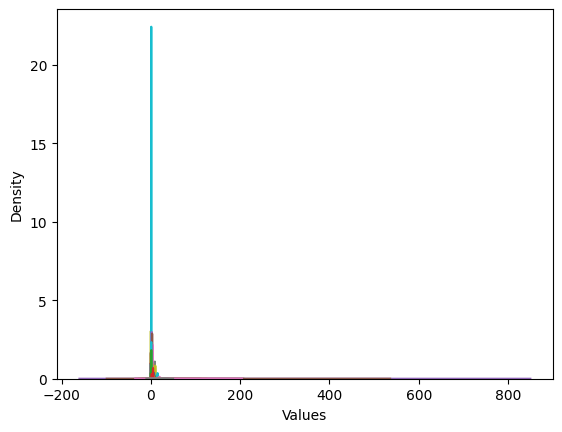

In [238]:
fig, ax = plt.subplots()

for j in range(X.shape[1]):
    ax = sns.kdeplot(X.iloc[:, j], ax=ax, label=f'feature{j}')

ax.set_ylabel('Density')
ax.set_xlabel('Values')
plt.show()

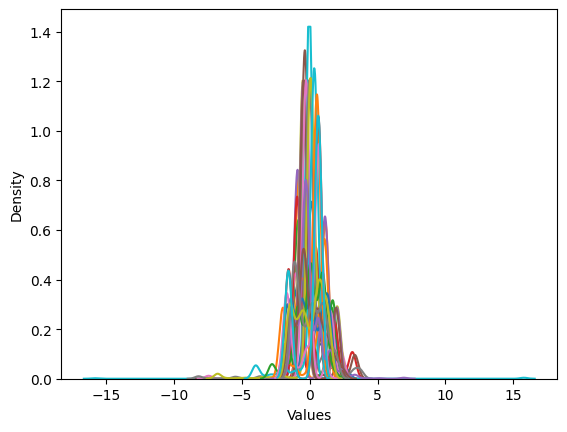

In [239]:
scaler = StandardScaler()
X_scaled_st = scaler.fit_transform(X)

X_scaled_st = pd.DataFrame(
    X_scaled_st,
    columns=X.columns,
    index=X.index
)

fig, ax = plt.subplots()

for j in range(30):
    ax = sns.kdeplot(X_scaled_st.iloc[:, j], ax=ax, label=f'feature{j}')

ax.set_ylabel('Density')
ax.set_xlabel('Values')
plt.show()

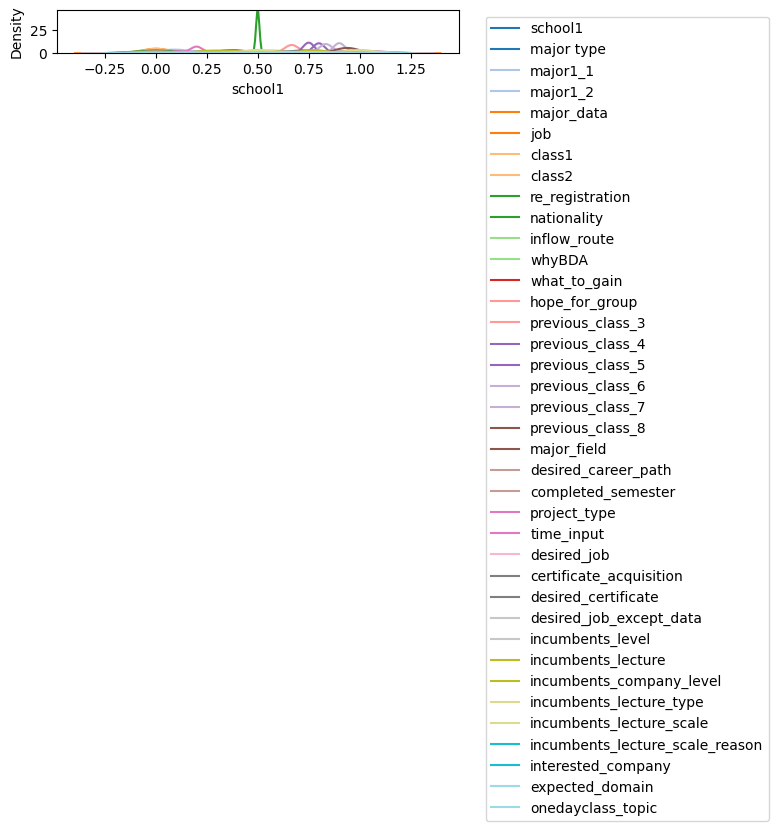

In [240]:
MinMax = MinMaxScaler()
X_scaled_mm = MinMax.fit_transform(X)

X_scaled_mm = pd.DataFrame(
    X_scaled_mm,
    columns=X.columns,
    index=X.index
)

n_features = X_scaled_mm.shape[1]
colors = plt.cm.tab20(np.linspace(0, 1, n_features))

fig, ax = plt.subplots(figsize=(8,5))

for j in range(n_features):
    col_name = X_scaled_mm.columns[j]
    sns.kdeplot(
        X_scaled_mm.iloc[:, j],
        ax=ax,
        label=col_name,
        color=colors[j]
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


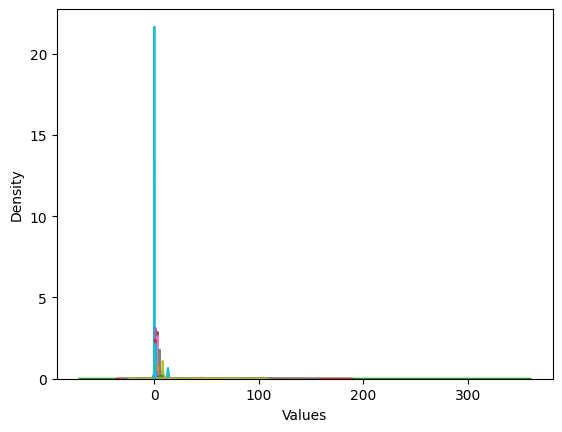

In [241]:
fig, ax = plt.subplots()

for j in range(30):
    ax = sns.kdeplot(test_x.iloc[:, j], ax=ax, label=f'feature{j}')

ax.set_ylabel('Density')
ax.set_xlabel('Values')
plt.show()

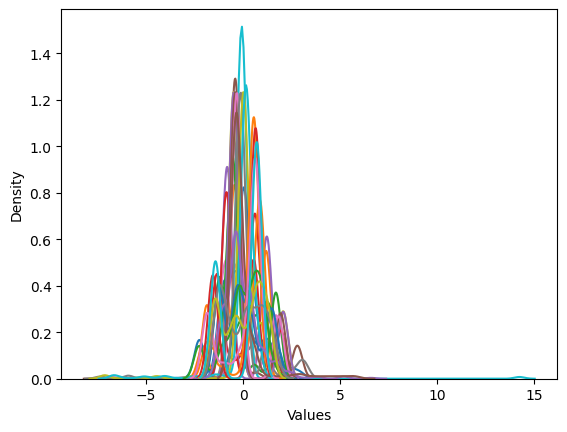

In [242]:
scaler = StandardScaler()
test_x_scaled_st = scaler.fit_transform(test_x)

test_x_scaled_st = pd.DataFrame(
    test_x_scaled_st,
    columns=test_x.columns,
    index=test_x.index
)

fig, ax = plt.subplots()

for j in range(30):
    ax = sns.kdeplot(test_x_scaled_st.iloc[:, j], ax=ax, label=f'feature{j}')

ax.set_ylabel('Density')
ax.set_xlabel('Values')
plt.show()

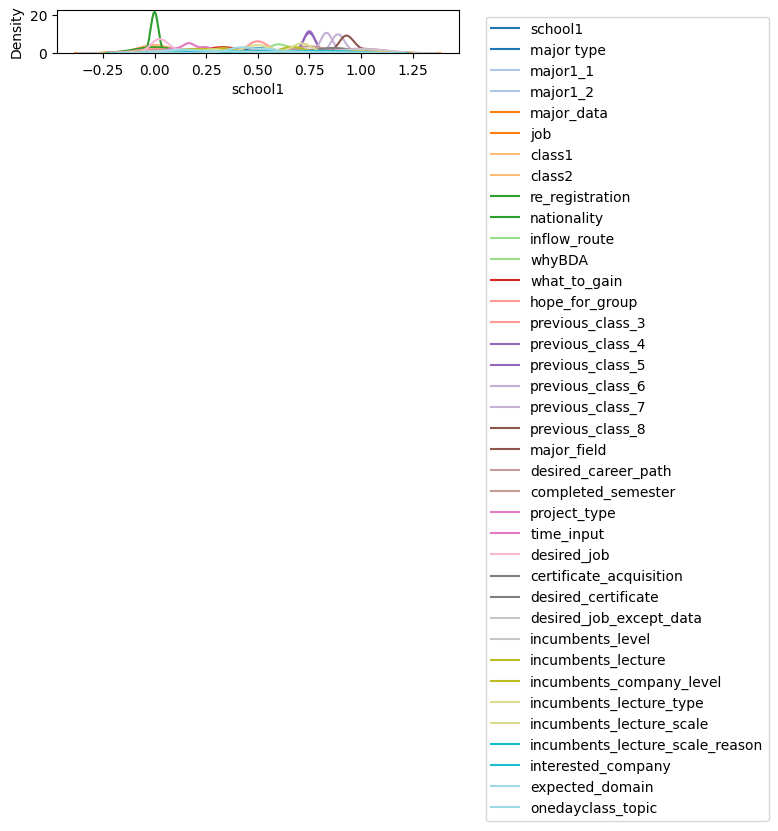

In [243]:
MinMax = MinMaxScaler()
test_x_scaled_mm = MinMax.fit_transform(test_x)

test_x_scaled_mm = pd.DataFrame(
    test_x_scaled_mm,
    columns=test_x.columns,
    index=test_x.index
)

n_features = test_x_scaled_mm.shape[1]
colors = plt.cm.tab20(np.linspace(0, 1, n_features))

fig, ax = plt.subplots(figsize=(8,5))

for j in range(n_features):
    col_name = X.columns[j]
    sns.kdeplot(
        test_x_scaled_mm.iloc[:, j],
        ax=ax,
        label=col_name,
        color=colors[j]
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# 불필요 열 제거

<Axes: >

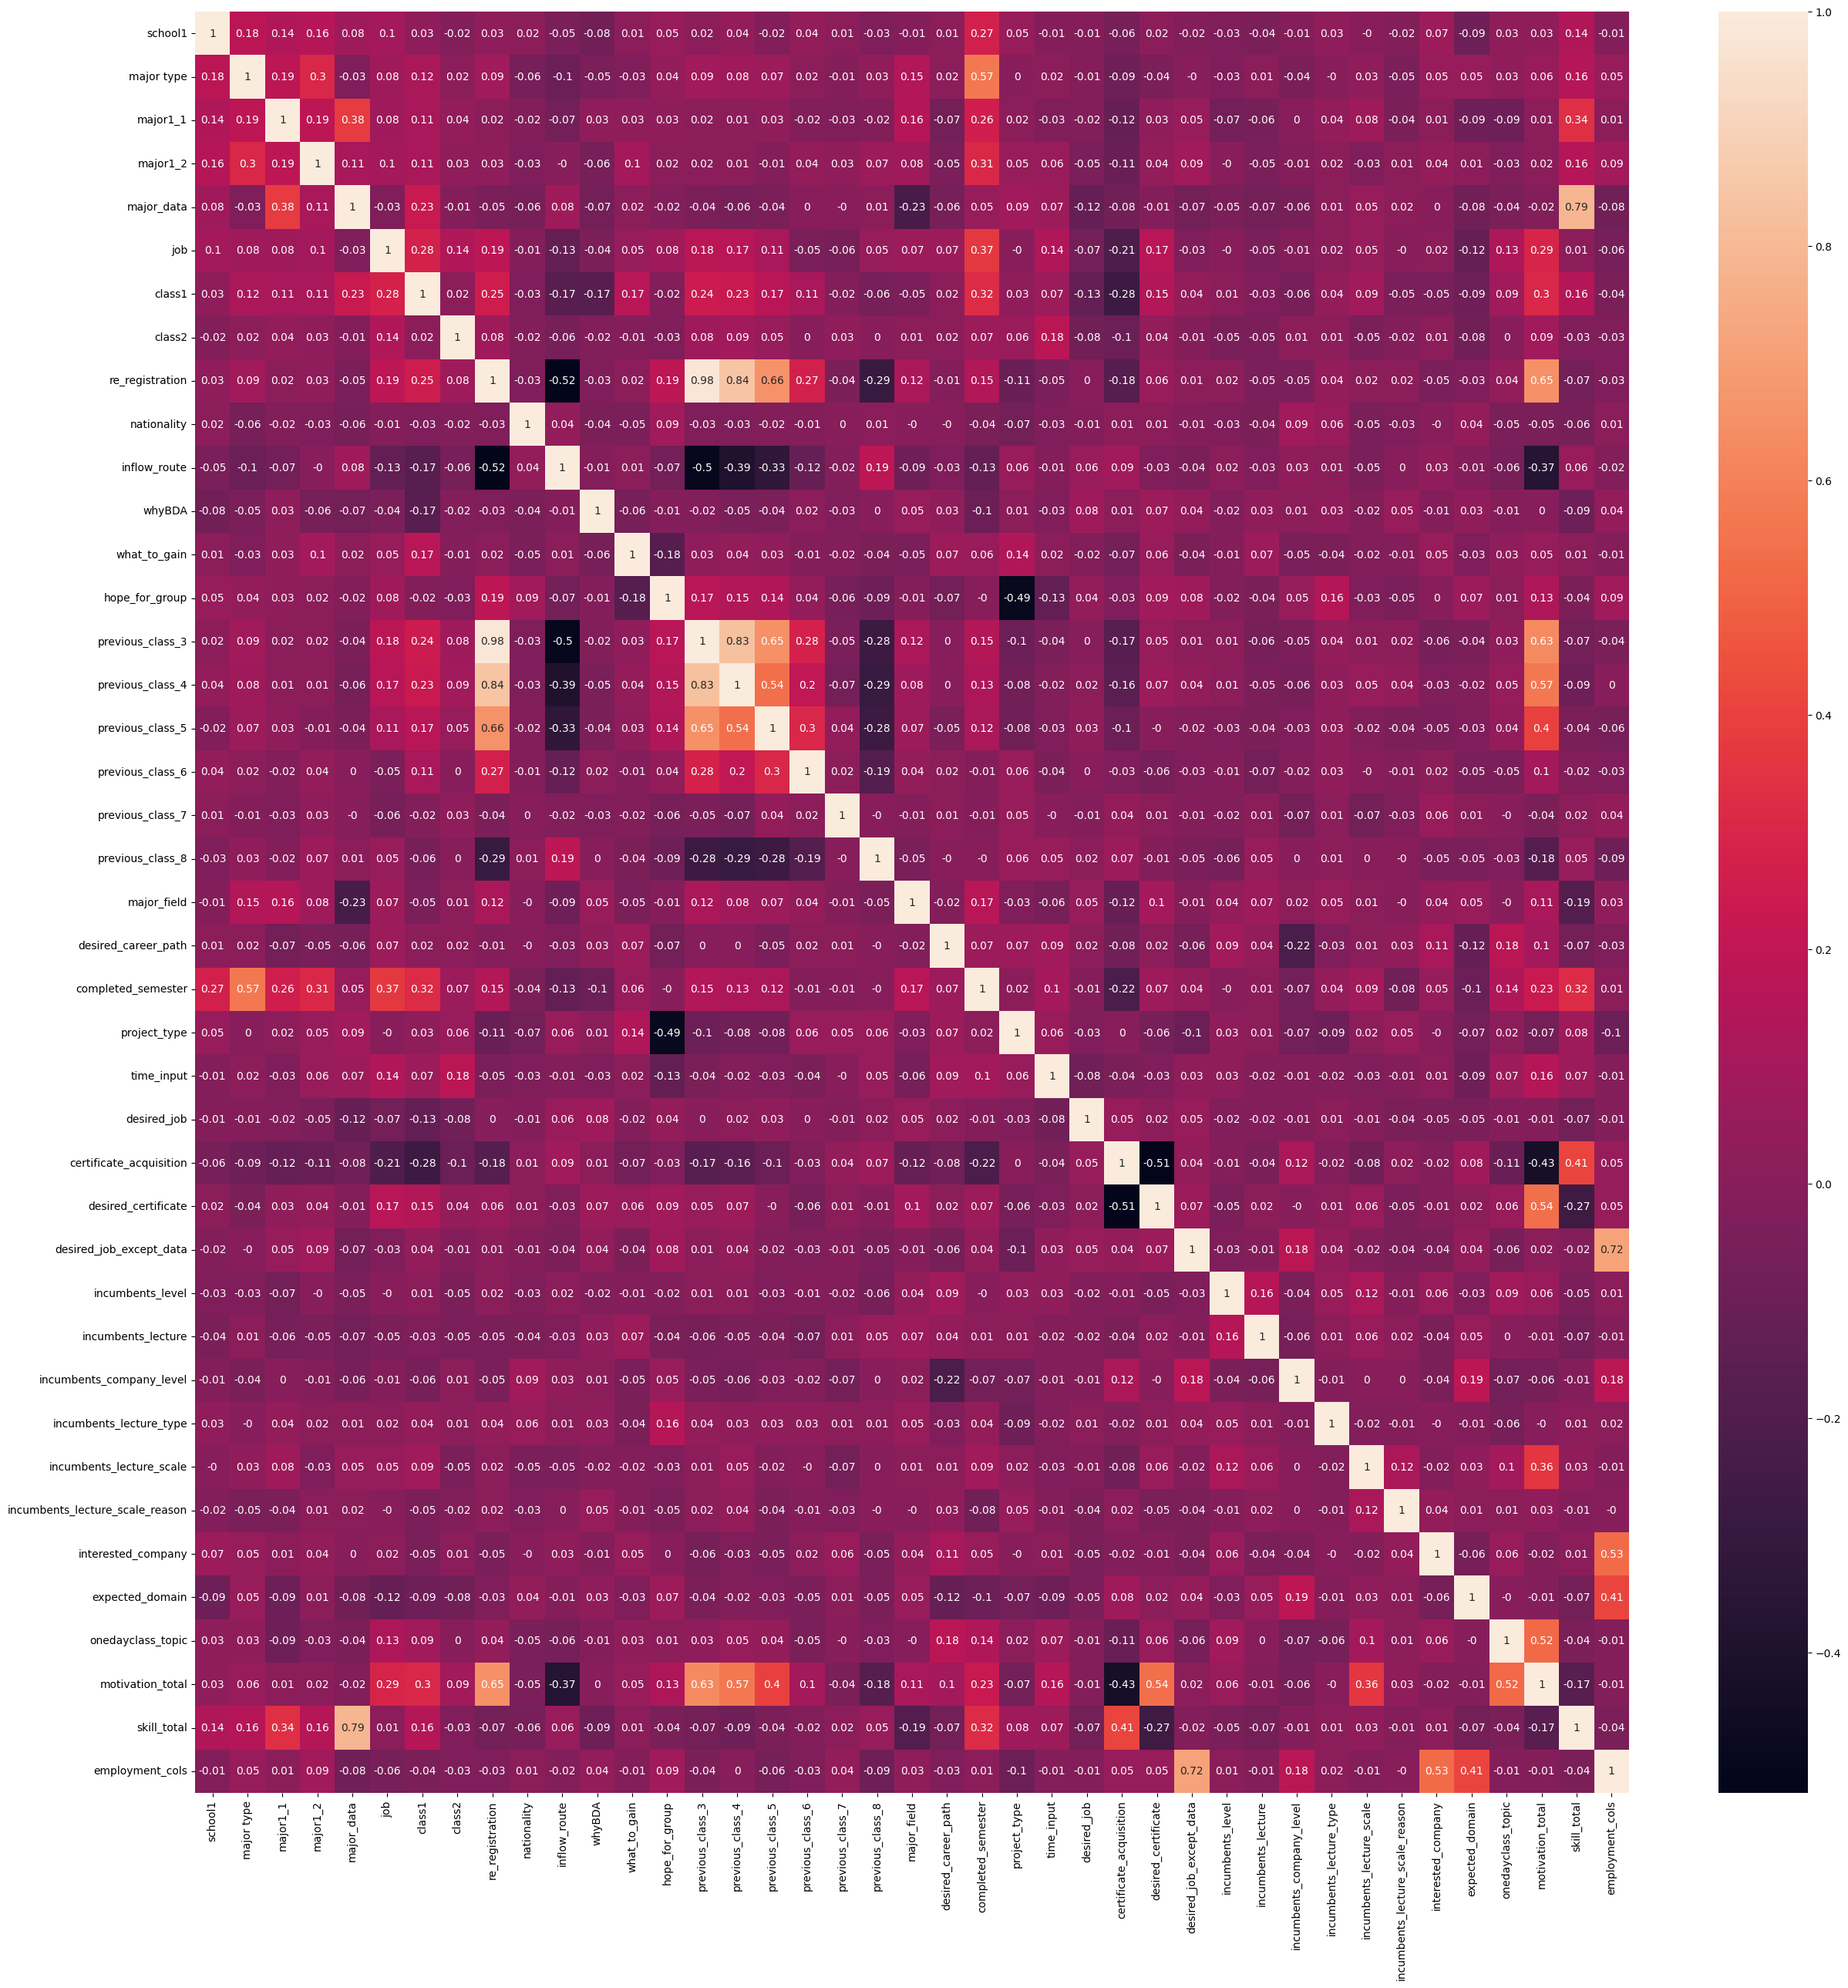

In [247]:
plt.figure(figsize=(30,30))
sns.heatmap(test_x_scaled_mm.corr().round(2), annot = True)

<Axes: >

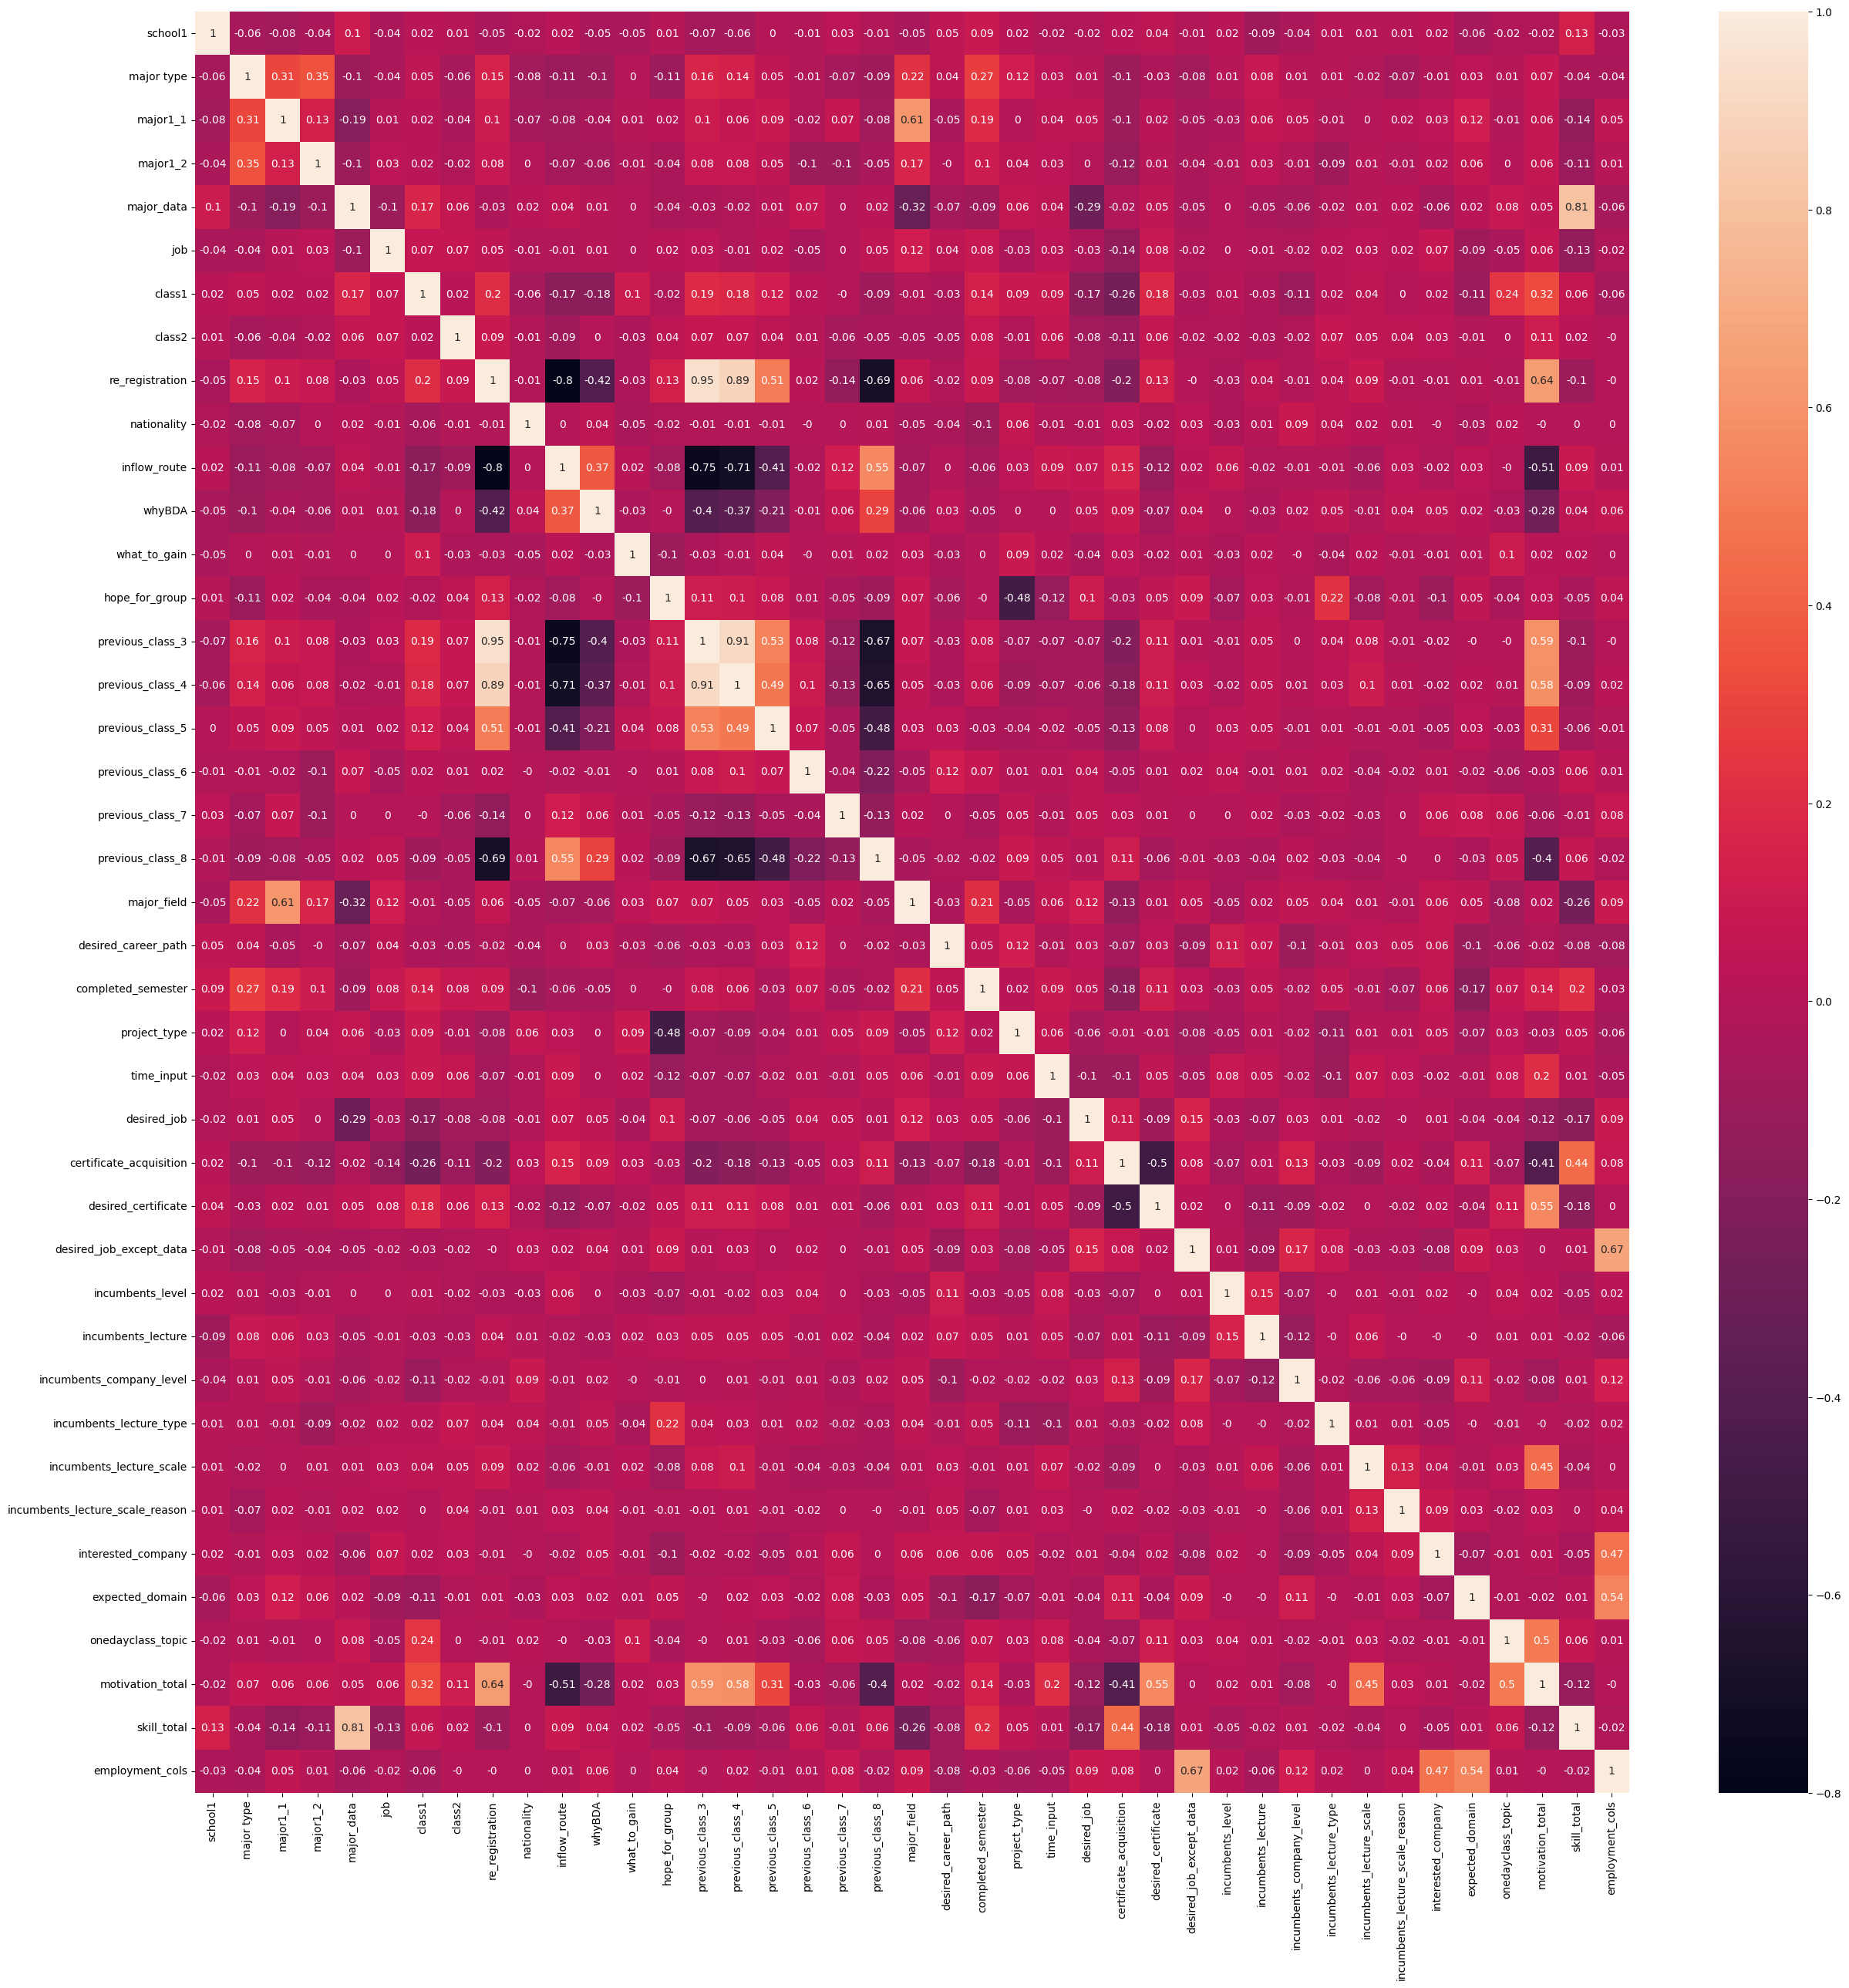

In [248]:
plt.figure(figsize=(30,30))
sns.heatmap(X_scaled_mm.corr().round(2), annot = True)

In [249]:
drop_col = ['re_registration','inflow_route','previous_class_3','previous_class_4','previous_class_8','major_field','motivation_total','skill_total','employment_cols']
X_scaled_mm = X_scaled_mm.drop(columns=drop_col)
test_x_scaled_mm = test_x_scaled_mm.drop(columns=drop_col)

<Axes: >

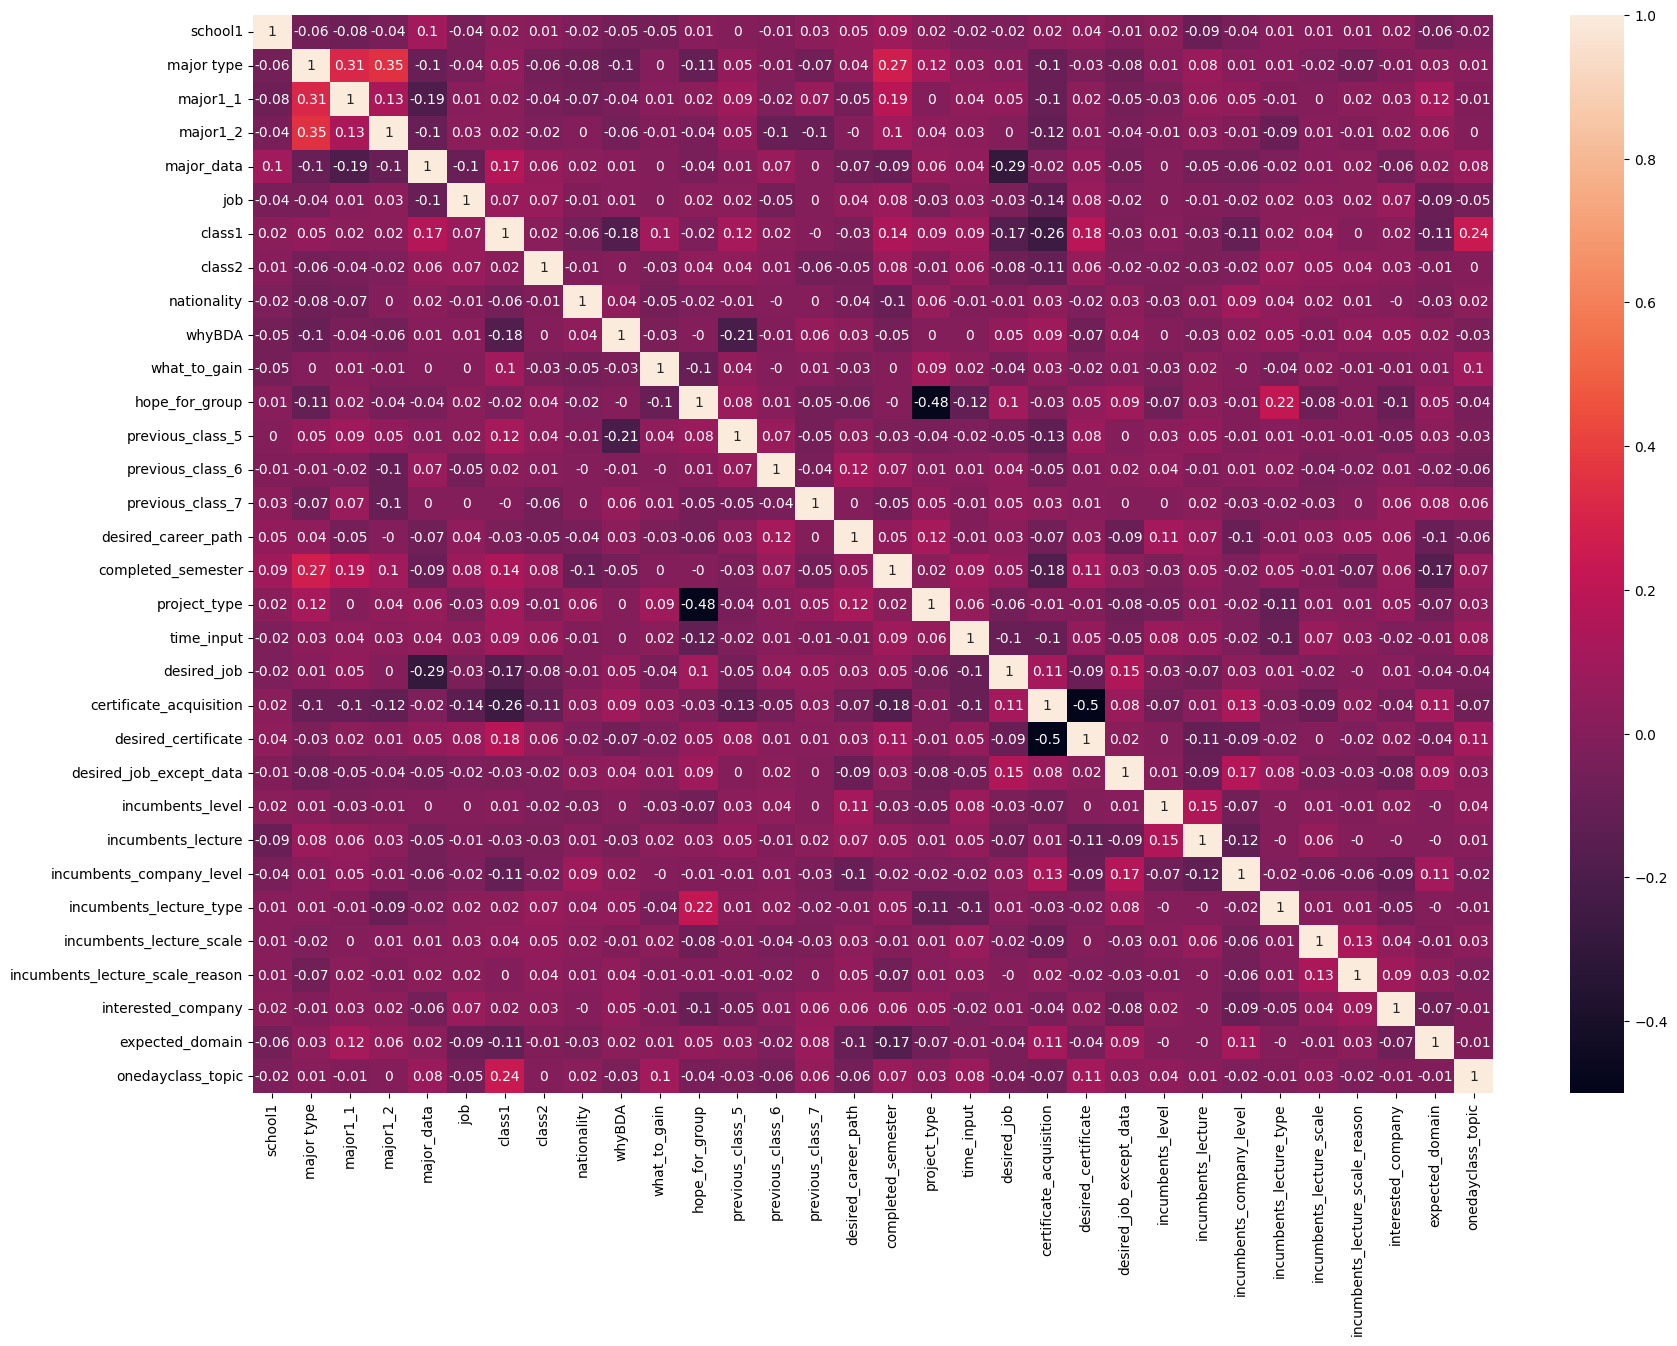

In [250]:
plt.figure(figsize=(20,14))
sns.heatmap(X_scaled_mm.corr().round(2), annot = True)

#CatBoost

In [328]:
# 모델 설정 및 교차 검증
n_splits = 5

skf = StratifiedKFold(n_splits=n_splits, shuffle= True, random_state=42)

oof_preds = np.zeros(len(X_scaled_mm))
test_preds = np.zeros(len(test_x_scaled_mm))


model = CatBoostClassifier(
    random_seed=42
    )

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_scaled_mm, y), start=1):
    X_tr, X_va = X_scaled_mm.iloc[tr_idx], X_scaled_mm.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    train_pool = Pool(X_tr, y_tr)
    val_pool = Pool(X_va, y_va)
    test_pool = Pool(test_x_scaled_mm)

    model.fit(train_pool, eval_set=val_pool)

    oof_preds[va_idx] = model.predict_proba(val_pool)[:, 1]
    test_preds += model.predict_proba(test_pool)[:, 1] / n_splits

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
29:	learn: 0.5596358	test: 0.6143849	best: 0.6143849 (29)	total: 234ms	remaining: 7.57s
30:	learn: 0.5563000	test: 0.6137368	best: 0.6137368 (30)	total: 241ms	remaining: 7.53s
31:	learn: 0.5539534	test: 0.6115602	best: 0.6115602 (31)	total: 250ms	remaining: 7.55s
32:	learn: 0.5517569	test: 0.6110810	best: 0.6110810 (32)	total: 255ms	remaining: 7.47s
33:	learn: 0.5501869	test: 0.6107090	best: 0.6107090 (33)	total: 261ms	remaining: 7.42s
34:	learn: 0.5480116	test: 0.6100152	best: 0.6100152 (34)	total: 264ms	remaining: 7.29s
35:	learn: 0.5458355	test: 0.6090398	best: 0.6090398 (35)	total: 275ms	remaining: 7.36s
36:	learn: 0.5441389	test: 0.6088811	best: 0.6088811 (36)	total: 281ms	remaining: 7.3s
37:	learn: 0.5426518	test: 0.6080895	best: 0.6080895 (37)	total: 286ms	remaining: 7.23s
38:	learn: 0.5403497	test: 0.6074071	best: 0.6074071 (38)	total: 293ms	remaining: 7.22s
39:	learn: 0.5376899	test: 0.6063002	best: 0.6063002 (39)	total: 300ms	remaining: 7.2

In [329]:
best_t, best_f1 = 0.5, -1.0
for t in np.linspace(0.01, 0.99, 199):
    pred = (oof_preds >= t).astype(int)
    f1 = f1_score(y, pred)
    if f1 > best_f1:
        best_f1, best_t = f1, float(t)

print(f"[OOF] best_f1={best_f1:.6f}, best_t={best_t:.3f}, oof_pred_pos_rate={(oof_preds>=best_t).mean():.3f}")


[OOF] best_f1=0.473480, best_t=0.253, oof_pred_pos_rate=0.735


# 제출

In [330]:
prediction = (test_preds > best_t).astype(int)

In [331]:
prediction

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [327]:
sample_submission['completed'] = prediction
sample_submission.to_csv("submission_cb3.csv",index=False)